# Text Feature Engineering Assignment (Real-world Dataset)

**Problem Statement:** Build a Text Processing Pipeline to analyze real user-generated text data (reviews/comments) and convert them into numerical features for machine learning models.

**Pipeline:** Data Collection → Preprocessing → Vocabulary → Feature Engineering (OHE, BoW, TF-IDF) → Analysis → Sentiment Classification

In [60]:
import os
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')


# NLTK setup
import nltk
for resource in ['punkt', 'punkt_tab', 'stopwords', 'wordnet']:
    try:
        nltk.data.find(f'tokenizers/{resource}' if 'punkt' in resource else f'corpora/{resource}')
    except LookupError:
        nltk.download(resource, quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

print("All imports successful!")

All imports successful!


## Dataset Collection (Real-world)

Scraped product reviews from **Flipkart** dynamically based on user input.
- Uses **Playwright** (headless browser — bypasses reCAPTCHA)
- Extracts `review_text` (title + body) and `rating` from embedded JSON
- Stored in CSV with `review_text`, `rating` columns

### ▶ Run Scraper (Dynamic URL Input)
Run the cell below and paste any **Flipkart** product URL when prompted.

In [62]:
import subprocess, sys

# Paste your Flipkart product URL below
url = "https://www.flipkart.com/noise-masterbuds-2-sound-bose-51db-anc-hi-res-lhdc-spatial-audio-ai-assistance-bluetooth/product-reviews/itmf87f273ad4b0f"
MAX_REVIEWS = 1000

# Auto-detect product name from URL
PRODUCT_NAME = url.split("flipkart.com/")[-1].split("/")[0].replace("-", "_")
csv_path = f"data/raw/flip_{PRODUCT_NAME[:15]}_reviews.csv"
os.makedirs(os.path.dirname(csv_path), exist_ok=True)

# Run scraper as subprocess (Playwright sync API can't run inside Jupyter's asyncio loop)
print(f"[*] Scraping reviews from Flipkart...")
print(f"[*] URL: {url[:80]}...")
print(f"[*] Max reviews: {MAX_REVIEWS}")
print(f"[*] Output: {csv_path}\n")

result = subprocess.run(
    [sys.executable, "scraper.py", url, str(MAX_REVIEWS), csv_path],
    capture_output=True, text=True, cwd=os.path.dirname(os.path.abspath("scraper.py")) or "."
)

# Show scraper output
if result.stdout:
    print(result.stdout)
if result.stderr:
    print("[STDERR]", result.stderr[:500])

# Load scraped CSV
if os.path.exists(csv_path):
    df_raw = pd.read_csv(csv_path)
    print(f"\n[OK] Loaded {len(df_raw)} reviews from: {csv_path}")
    print(f"Columns: {list(df_raw.columns)}")
    print(f"\nRating distribution:\n{df_raw['rating'].value_counts().sort_index()}")
    display(df_raw.head())
else:
    print("[!] CSV not created — scraper may have failed")

[*] Scraping reviews from Flipkart...
[*] URL: https://www.flipkart.com/noise-masterbuds-2-sound-bose-51db-anc-hi-res-lhdc-spat...
[*] Max reviews: 1000
[*] Output: data/raw/flip_noise_masterbud_reviews.csv

  Page 1: +10 (Total: 10)
  Page 2: +10 (Total: 20)
  Page 3: +10 (Total: 30)
  Page 4: +10 (Total: 40)
  Page 5: +10 (Total: 50)
  Page 6: +9 (Total: 59)
  Page 7: +10 (Total: 69)
  Page 8: +5 (Total: 74)
[!] No reviews on 3 consecutive pages. Stopping.

[OK] Scraped 74 reviews from Flipkart
[OK] Saved to data/raw/flip_noise_masterbud_reviews.csv


[OK] Loaded 74 reviews from: data/raw/flip_noise_masterbud_reviews.csv
Columns: ['review_text', 'rating']

Rating distribution:
rating
1     4
2     2
4     3
5    65
Name: count, dtype: int64


,review_text,rating
0,Wonderful Great sounds i love this product,5
1,Mind-blowing purchase Sound quality is very go...,5
2,Fabulous! Best product i ever purchased,5
3,Perfect product! Great sound quality,5
4,Classy product Excellent sound quality with st...,5


---
## Task 1: Preprocessing

Steps:
1. Convert text to **lowercase**
2. **Tokenization** (split into words)
3. **Remove punctuation** and special characters
4. **Remove stopwords** (and, a, the, is, etc.)
5. **Lemmatization** (reduce words to base form)

In [65]:
# TASK 1: TEXT PREPROCESSING


stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if not isinstance(text, str) or not text.strip():
        return ""
    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)
 
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = word_tokenize(text)

    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]

    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    
    return ' '.join(tokens)


# preprocessing
df = df_raw.copy()
df['cleaned_text'] = df['review_text'].apply(preprocess_text)

# Remove empty rows after cleaning
df = df[df['cleaned_text'].str.strip().astype(bool)].reset_index(drop=True)

# Show before vs after
# print("=" * 70)
# print("PREPROCESSING RESULTS")
# print("=" * 70)
print(f"Reviews before cleaning: {len(df_raw)}")
print(f"Reviews after cleaning:  {len(df)}")

print("EXAMPLE - Before vs After:")
for i in range(min(2, len(df))):
    print(f"  BEFORE: {df_raw['review_text'].iloc[i][:120]}...")
    print(f"  AFTER:  {df['cleaned_text'].iloc[i][:120]}...")

Reviews before cleaning: 74
Reviews after cleaning:  74
EXAMPLE - Before vs After:
  BEFORE: Wonderful Great sounds  i love this product...
  AFTER:  wonderful great sound love product...
  BEFORE: Mind-blowing purchase Sound quality is very good, with a nice balance of bass and clarity....
  AFTER:  mindblowing purchase sound quality good nice balance bass clarity...


## Task 2: Vocabulary Creation

Build vocabulary from the cleaned text, print vocabulary size, and analyze top frequent words.

Total words (with repetition): 492
Vocabulary size (unique words): 190
Word                       Frequency
  product                         29
  sound                           28
  quality                         19
  good                            19
  best                            19
  excellent                       13
  awesome                         13
  buy                             10
  fabulous                         9
  anc                              9
  premium                          9
  great                            8
  worth                            7
  super                            7
  must                             7
  design                           6
  audio                            6
  purchase                         5
  nice                             5
  bass                             5


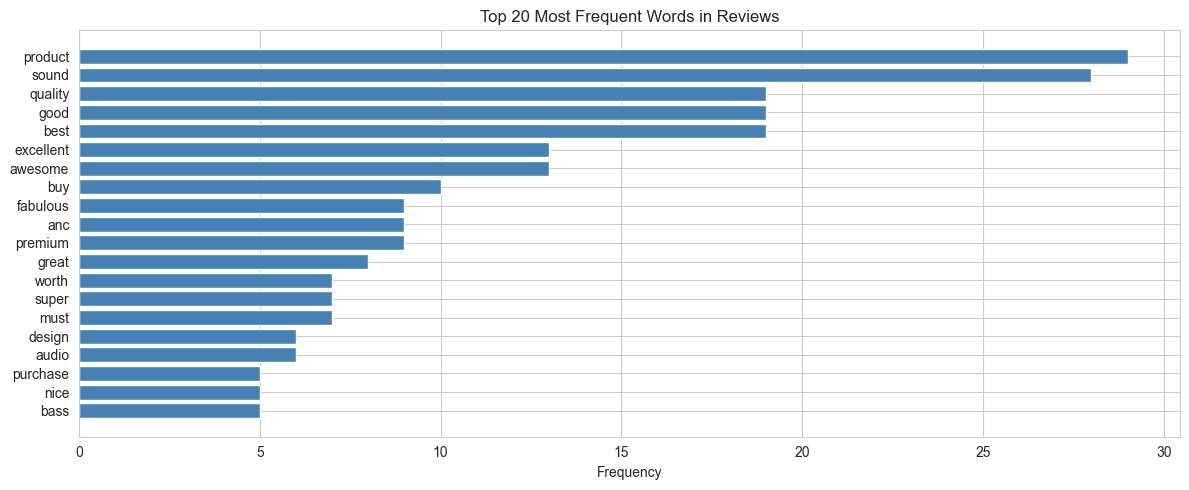

In [67]:
# VOCABULARY CREATION


texts = df['cleaned_text'].tolist()

all_words = []
for text in texts:
    all_words.extend(text.split())

vocabulary = sorted(set(all_words))
word_to_idx = {word: idx for idx, word in enumerate(vocabulary)}

print(f"Total words (with repetition): {len(all_words)}")
print(f"Vocabulary size (unique words): {len(vocabulary)}")

# Top frequent words
word_freq = Counter(all_words)
top_20 = word_freq.most_common(20)

print(f"{'Word':<25} {'Frequency':>10}")
for word, count in top_20:
    print(f"  {word:<25} {count:>8}")

# Visualize top words
fig, ax = plt.subplots(figsize=(12, 5))
words, counts = zip(*top_20)
ax.barh(range(len(words)), counts, color='steelblue')
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words)
ax.invert_yaxis()
ax.set_xlabel('Frequency')
ax.set_title('Top 20 Most Frequent Words in Reviews')
plt.tight_layout()
plt.show()

---
## Task 3: Feature Engineering

### a.) One-Hot Encoding 
### b.) Bag of Words (CountVectorizer)
### c.) TF-IDF (TfidfVectorizer)

In [68]:
# TASK 3: FEATURE ENGINEERING
#  One-Hot Encoding 
print("ONE-HOT ENCODING")


vocab_size = len(vocabulary)
n_docs = len(texts)

ohe_matrix = np.zeros((n_docs, vocab_size), dtype=int)
for i, text in enumerate(texts):
    words_in_doc = set(text.split())
    for word in words_in_doc:
        if word in word_to_idx:
            ohe_matrix[i, word_to_idx[word]] = 1

print(f"OHE Matrix Shape: {ohe_matrix.shape}")
print(f"  → {n_docs} documents × {vocab_size} unique words")
print(f"\nSample (first 3 docs, first 10 words):")
sample_words = vocabulary[:10]
ohe_sample = pd.DataFrame(ohe_matrix[:3, :10], columns=sample_words)
display(ohe_sample)

# Bag of Words
print("BAG OF WORDS (CountVectorizer)")

bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(texts)

print(f"BoW Matrix Shape: {bow_matrix.shape}")
bow_features = bow_vectorizer.get_feature_names_out()
print(f"Vocabulary size: {len(bow_features)}")

print(f"\nSample (first 3 docs, first 10 features):")
bow_sample = pd.DataFrame(
    bow_matrix[:3, :10].toarray(),
    columns=bow_features[:10]
)
display(bow_sample)

# Top words by total count
word_counts = np.asarray(bow_matrix.sum(axis=0)).flatten()
top_bow_idx = word_counts.argsort()[-10:][::-1]
print("\nTop 10 words by frequency (BoW):")
for idx in top_bow_idx:
    print(f"  {bow_features[idx]:<20} count: {int(word_counts[idx])}")

# TF-IDF
print("TF-IDF (TfidfVectorizer)")

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(texts)

print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")
tfidf_features = tfidf_vectorizer.get_feature_names_out()
print(f"Vocabulary size: {len(tfidf_features)}")

print(f"\nSample (first 3 docs, first 10 features):")
tfidf_sample = pd.DataFrame(
    tfidf_matrix[:3, :10].toarray().round(4),
    columns=tfidf_features[:10]
)
display(tfidf_sample)

# Top words by average TF-IDF score
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
top_tfidf_idx = mean_tfidf.argsort()[-10:][::-1]
print("\nTop 10 words by average TF-IDF score:")
for idx in top_tfidf_idx:
    print(f"  {tfidf_features[idx]:<20} avg TF-IDF: {mean_tfidf[idx]:.4f}")

ONE-HOT ENCODING
OHE Matrix Shape: (74, 190)
  → 74 documents × 190 unique words

Sample (first 3 docs, first 10 words):


,absolutely,accurate,activity,amazing,anc,android,apple,attractive,audio,awesome
0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0


BAG OF WORDS (CountVectorizer)
BoW Matrix Shape: (74, 190)
Vocabulary size: 190

Sample (first 3 docs, first 10 features):


,absolutely,accurate,activity,amazing,anc,android,apple,attractive,audio,awesome
0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0



Top 10 words by frequency (BoW):
  product              count: 29
  sound                count: 28
  quality              count: 19
  best                 count: 19
  good                 count: 19
  excellent            count: 13
  awesome              count: 13
  buy                  count: 10
  fabulous             count: 9
  anc                  count: 9
TF-IDF (TfidfVectorizer)
TF-IDF Matrix Shape: (74, 190)
Vocabulary size: 190

Sample (first 3 docs, first 10 features):


,absolutely,accurate,activity,amazing,anc,android,apple,attractive,audio,awesome
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Top 10 words by average TF-IDF score:
  product              avg TF-IDF: 0.1047
  best                 avg TF-IDF: 0.0912
  good                 avg TF-IDF: 0.0898
  sound                avg TF-IDF: 0.0841
  awesome              avg TF-IDF: 0.0682
  quality              avg TF-IDF: 0.0618
  excellent            avg TF-IDF: 0.0571
  great                avg TF-IDF: 0.0521
  fabulous             avg TF-IDF: 0.0518
  super                avg TF-IDF: 0.0517


---
## Task 4: Comparison Analysis
Compare One-Hot Encoding, Bag of Words, and TF-IDF methods. Analyze which words are most important in TF-IDF and explain why common words receive lower weight.

In [69]:
#  COMPARISON ANALYSIS


from scipy.sparse import issparse

def calc_sparsity(matrix):
    """Calculate percentage of zero values in a matrix."""
    if issparse(matrix):
        total = matrix.shape[0] * matrix.shape[1]
        nonzero = matrix.nnz
    else:
        total = matrix.size
        nonzero = np.count_nonzero(matrix)
    return ((total - nonzero) / total) * 100

# ─── Comparison Table ───────────────────────────────────────────────────
comparison_data = {
    'Method': ['One-Hot Encoding (OHE)', 'Bag of Words (BoW)', 'TF-IDF'],
    'Shape': [str(ohe_matrix.shape), str(bow_matrix.shape), str(tfidf_matrix.shape)],
    'Value Type': ['Binary (0 or 1)', 'Integer (word counts)', 'Float (weighted scores)'],
    'Considers Word Frequency': ['❌ No', '✅ Yes', '✅ Yes'],
    'Considers Word Importance': ['❌ No', '❌ No', '✅ Yes (IDF weighting)'],
    'Handles Common Words': ['❌ No', '❌ No', '✅ Yes (down-weights them)'],
    'Sparsity (%)': [
        f"{calc_sparsity(ohe_matrix):.2f}%",
        f"{calc_sparsity(bow_matrix):.2f}%",
        f"{calc_sparsity(tfidf_matrix):.2f}%"
    ],
    'Best Use Case': [
        'Simple presence/absence check',
        'Text classification, simple models',
        'Information retrieval, search, advanced NLP'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("=" * 80)
print("COMPARISON TABLE: OHE vs BoW vs TF-IDF")
print("=" * 80)
display(comparison_df)

# ─── Why common words get lower weight in TF-IDF ───────────────────────
print("\n" + "=" * 80)
print("WHY COMMON WORDS RECEIVE LOWER WEIGHT IN TF-IDF")
print("=" * 80)
print("""
TF-IDF = Term Frequency (TF) × Inverse Document Frequency (IDF)

• TF(t,d) = (Number of times term t appears in doc d) / (Total terms in doc d)
• IDF(t)  = log(Total documents / Number of documents containing term t)

Key Insight:
→ If a word appears in MANY documents, its IDF becomes very LOW (close to 0)
→ Words like "good", "product", "nice" appear in almost every review
→ Their IDF ≈ log(N/N) ≈ log(1) ≈ 0, so TF-IDF ≈ 0
→ Rare, discriminative words get HIGH TF-IDF scores because IDF is large
→ This automatically identifies the MOST IMPORTANT words per document
""")

# Show most vs least important words
print("Most important words (highest TF-IDF):")
top_important = mean_tfidf.argsort()[-10:][::-1]
for idx in top_important:
    print(f"  ✅ {tfidf_features[idx]:<20} avg score: {mean_tfidf[idx]:.4f}")

print("\nLeast important words (lowest non-zero TF-IDF):")
nonzero_mask = mean_tfidf > 0
nonzero_scores = mean_tfidf[nonzero_mask]
nonzero_features = tfidf_features[nonzero_mask]
bottom_important = nonzero_scores.argsort()[:10]
for idx in bottom_important:
    print(f"  ⬇️  {nonzero_features[idx]:<20} avg score: {nonzero_scores[idx]:.4f}")

COMPARISON TABLE: OHE vs BoW vs TF-IDF


,Method,Shape,Value Type,Considers Word Frequency,Considers Word Importance,Handles Common Words,Sparsity (%),Best Use Case
0,One-Hot Encoding (OHE),"(74, 190)",Binary (0 or 1),❌ No,❌ No,❌ No,96.56%,Simple presence/absence check
1,Bag of Words (BoW),"(74, 190)",Integer (word counts),✅ Yes,❌ No,❌ No,96.56%,"Text classification, simple models"
2,TF-IDF,"(74, 190)",Float (weighted scores),✅ Yes,✅ Yes (IDF weighting),✅ Yes (down-weights them),96.56%,"Information retrieval, search, advanced NLP"



WHY COMMON WORDS RECEIVE LOWER WEIGHT IN TF-IDF

TF-IDF = Term Frequency (TF) × Inverse Document Frequency (IDF)

• TF(t,d) = (Number of times term t appears in doc d) / (Total terms in doc d)
• IDF(t)  = log(Total documents / Number of documents containing term t)

Key Insight:
→ If a word appears in MANY documents, its IDF becomes very LOW (close to 0)
→ Words like "good", "product", "nice" appear in almost every review
→ Their IDF ≈ log(N/N) ≈ log(1) ≈ 0, so TF-IDF ≈ 0
→ Rare, discriminative words get HIGH TF-IDF scores because IDF is large
→ This automatically identifies the MOST IMPORTANT words per document

Most important words (highest TF-IDF):
  ✅ product              avg score: 0.1047
  ✅ best                 avg score: 0.0912
  ✅ good                 avg score: 0.0898
  ✅ sound                avg score: 0.0841
  ✅ awesome              avg score: 0.0682
  ✅ quality              avg score: 0.0618
  ✅ excellent            avg score: 0.0571
  ✅ great                avg score: 0.

---
## Task 5: Sparse Matrix Analysis

Analyze the shape, sparsity (percentage of zeros), and explain why sparse matrices are inefficient for large-scale systems.

SPARSE MATRIX ANALYSIS

──────────────────────────────────────────────────
  One-Hot Encoding
──────────────────────────────────────────────────
  Shape:         74 × 190
  Total:         14,060 elements
  Non-zero:      484
  Zeros:         13,576
  Sparsity:      96.56%
  Memory (sparse): 54.9 KB
  Memory (dense):  54.9 KB

──────────────────────────────────────────────────
  Bag of Words
──────────────────────────────────────────────────
  Shape:         74 × 190
  Total:         14,060 elements
  Non-zero:      484
  Zeros:         13,576
  Sparsity:      96.56%
  Memory (sparse): 6.0 KB
  Memory (dense):  109.8 KB

──────────────────────────────────────────────────
  TF-IDF
──────────────────────────────────────────────────
  Shape:         74 × 190
  Total:         14,060 elements
  Non-zero:      484
  Zeros:         13,576
  Sparsity:      96.56%
  Memory (sparse): 6.0 KB
  Memory (dense):  109.8 KB

SUMMARY TABLE


,Matrix,Shape,Total Elements,Non-Zero Elements,Zero Elements,Sparsity (%),Sparse Memory (KB),Dense Memory (KB)
0,One-Hot Encoding,74 × 190,"14,060",484,"13,576",96.56%,54.9,54.9
1,Bag of Words,74 × 190,"14,060",484,"13,576",96.56%,6.0,109.8
2,TF-IDF,74 × 190,"14,060",484,"13,576",96.56%,6.0,109.8


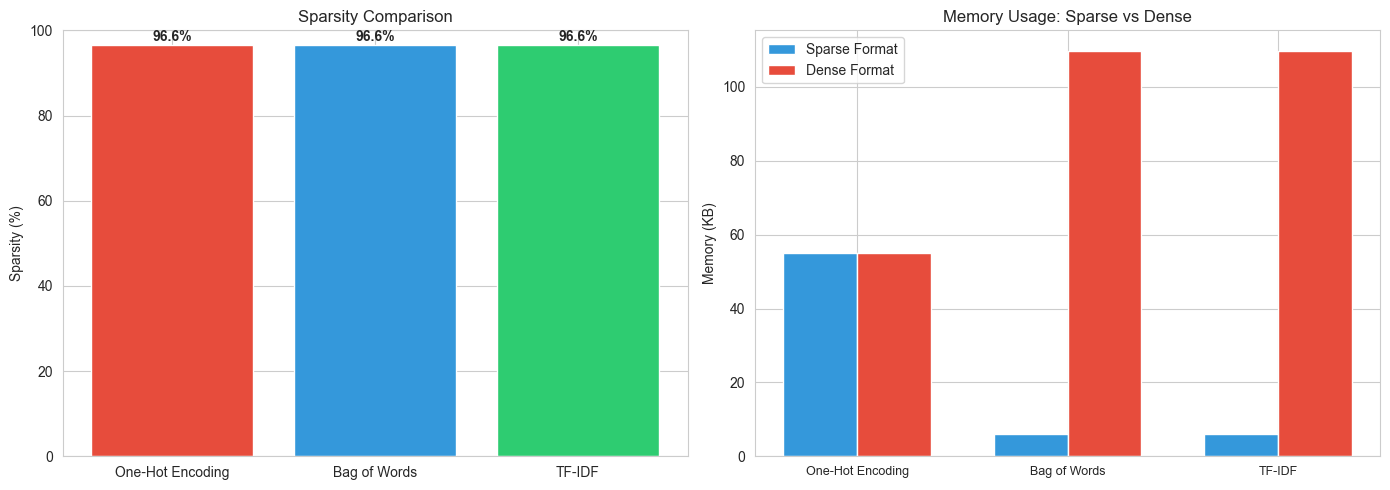


WHY SPARSE MATRICES ARE INEFFICIENT FOR LARGE-SCALE SYSTEMS:
═══════════════════════════════════════════════════════════════

1. MEMORY WASTE: In dense format, >95% of stored values are zeros.
   With millions of documents and 100K+ vocabulary, this can require
   TERABYTES of memory for what should be a small dataset.

2. COMPUTATIONAL OVERHEAD: Operations on dense matrices perform
   multiplications with zeros, wasting CPU cycles. Matrix multiplication
   of an (N×V) matrix takes O(N×V²) even when most values are zero.

3. STORAGE: Saving dense representations to disk wastes storage space.
   A 100K-doc × 50K-vocab dense matrix = 40GB vs sparse = ~100MB.

4. BANDWIDTH: Moving large dense matrices between CPU/GPU or across
   network in distributed systems creates bottlenecks.

SOLUTION: Use sparse matrix formats (CSR, CSC, COO) which only store
non-zero elements, dramatically reducing memory and computation.
scikit-learn returns sparse matrices by default for exactly this reason.



In [70]:
# SPARSE MATRIX ANALYSIS
print("SPARSE MATRIX ANALYSIS")


matrices = {
    'One-Hot Encoding': ohe_matrix,
    'Bag of Words': bow_matrix,
    'TF-IDF': tfidf_matrix
}

results = []
for name, matrix in matrices.items():
    if issparse(matrix):
        rows, cols = matrix.shape
        total = rows * cols
        nonzero = matrix.nnz
    else:
        rows, cols = matrix.shape
        total = matrix.size
        nonzero = np.count_nonzero(matrix)
    
    zeros = total - nonzero
    sparsity = (zeros / total) * 100
    
    # Memory usage
    if issparse(matrix):
        mem_sparse = (matrix.data.nbytes + matrix.indices.nbytes + matrix.indptr.nbytes) / 1024
        mem_dense = (rows * cols * 8) / 1024  
    else:
        mem_sparse = matrix.nbytes / 1024
        mem_dense = mem_sparse
    
    results.append({
        'Matrix': name,
        'Shape': f"{rows} × {cols}",
        'Total Elements': f"{total:,}",
        'Non-Zero Elements': f"{nonzero:,}",
        'Zero Elements': f"{zeros:,}",
        'Sparsity (%)': f"{sparsity:.2f}%",
        'Sparse Memory (KB)': f"{mem_sparse:.1f}",
        'Dense Memory (KB)': f"{mem_dense:.1f}",
    })
    
    print(f"\n{'─'*50}")
    print(f"  {name}")
    print(f"{'─'*50}")
    print(f"  Shape:         {rows} × {cols}")
    print(f"  Total:         {total:,} elements")
    print(f"  Non-zero:      {nonzero:,}")
    print(f"  Zeros:         {zeros:,}")
    print(f"  Sparsity:      {sparsity:.2f}%")
    print(f"  Memory (sparse): {mem_sparse:.1f} KB")
    print(f"  Memory (dense):  {mem_dense:.1f} KB")

# Summary table
results_df = pd.DataFrame(results)
print(f"\n{'='*70}")
print("SUMMARY TABLE")
print(f"{'='*70}")
display(results_df)

# Visualization 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sparsity comparison
names = [r['Matrix'] for r in results]
sparsities = [float(r['Sparsity (%)'].replace('%','')) for r in results]
axes[0].bar(names, sparsities, color=['#e74c3c', '#3498db', '#2ecc71'])
axes[0].set_ylabel('Sparsity (%)')
axes[0].set_title('Sparsity Comparison')
axes[0].set_ylim(0, 100)
for i, v in enumerate(sparsities):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# Memory comparison
mem_sparse = [float(r['Sparse Memory (KB)']) for r in results]
mem_dense = [float(r['Dense Memory (KB)']) for r in results]
x = np.arange(len(names))
width = 0.35
axes[1].bar(x - width/2, mem_sparse, width, label='Sparse Format', color='#3498db')
axes[1].bar(x + width/2, mem_dense, width, label='Dense Format', color='#e74c3c')
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, fontsize=9)
axes[1].set_ylabel('Memory (KB)')
axes[1].set_title('Memory Usage: Sparse vs Dense')
axes[1].legend()

plt.tight_layout()
plt.show()

#Explanation 
print("""
WHY SPARSE MATRICES ARE INEFFICIENT FOR LARGE-SCALE SYSTEMS:
═══════════════════════════════════════════════════════════════

1. MEMORY WASTE: In dense format, >95% of stored values are zeros.
   With millions of documents and 100K+ vocabulary, this can require
   TERABYTES of memory for what should be a small dataset.

2. COMPUTATIONAL OVERHEAD: Operations on dense matrices perform
   multiplications with zeros, wasting CPU cycles. Matrix multiplication
   of an (N×V) matrix takes O(N×V²) even when most values are zero.

3. STORAGE: Saving dense representations to disk wastes storage space.
   A 100K-doc × 50K-vocab dense matrix = 40GB vs sparse = ~100MB.

4. BANDWIDTH: Moving large dense matrices between CPU/GPU or across
   network in distributed systems creates bottlenecks.

SOLUTION: Use sparse matrix formats (CSR, CSC, COO) which only store
non-zero elements, dramatically reducing memory and computation.
scikit-learn returns sparse matrices by default for exactly this reason.
""")

## Task 6: Real-world Questions

1. Why Bag of Words fails in understanding semantic meaning
2. When to use BoW and TF-IDF in industry
3. Limitations of TF-IDF in real applications

In [71]:
#  REAL-WORLD QUESTIONS


print("""
Q1: WHY BAG OF WORDS FAILS IN UNDERSTANDING SEMANTIC MEANING


BoW treats each word independently and ignores contex:

Example:
  Sentence A: "The food was not good"     → words: {food, not, good}
  Sentence B: "The food was good"          → words: {food, good}
  Sentence C: "The food was excellent"     → words: {food, excellent}

Problems:
  1. WORD ORDER IGNORED: "not good" and "good" both contain "good"
     → BoW gives similar vectors to opposite meanings!

  2. SYNONYMS NOT CAPTURED: "good" and "excellent" have similar meaning
     → But BoW treats them as completely DIFFERENT dimensions

  3. POLYSEMY IGNORED: "bank" (river bank vs. money bank)
     → BoW cannot distinguish word senses

  4. NO CONTEXT: "The battery lasts long" vs "I waited long for delivery"
     → "long" has different significance in each context

  5. NEGATION LOST: "I don't recommend" vs "I recommend"
     → Very different meanings, but BoW sees overlapping features

Q2: WHEN TO USE BAG OF WORDS AND TF-IDF IN INDUSTRY


USE BAG OF WORDS WHEN:
  • Simple text classification (spam detection, sentiment analysis)
  • Small to medium datasets
  • Baseline model before trying complex approaches
  • Feature importance/interpretability matters
  • Industry: Email filtering, customer support ticket routing

USE TF-IDF WHEN:
  • Information retrieval / search engines (ranking documents)
  • Document similarity and clustering
  • Keyword extraction from documents
  • Some words are much more informative than others
  • Industry: Legal document search, news categorization,
    recommendation systems, SEO content analysis

GENERAL RULE:
  • Start with TF-IDF (better performance in most cases)
  • Use BoW for quick prototyping or when simplicity is needed
  • For production NLP: consider Word2Vec, BERT, or transformer embeddings


 Q3: LIMITATIONS OF TF-IDF IN REAL APPLICATIONS 


  1. NO SEMANTIC UNDERSTANDING: Still treats words independently.
     "happy" and "joyful" remain completely separate features.

  2. HIGH DIMENSIONALITY: Vocabulary can be 50K-500K+ words,
     creating very high-dimensional, sparse feature spaces.

  3. OUT-OF-VOCABULARY (OOV): Cannot handle words not seen during
     training. New products, slang, or typos are ignored.

  4. WORD ORDER LOST: Like BoW, "not good" ≠ "good" distinction
     is still not captured.

  5. DOMAIN SENSITIVITY: IDF weights computed on one corpus don't
     transfer well to another domain.

  6. DOESN'T SCALE FOR DEEP LEARNING: Modern NLP uses dense
     embeddings (Word2Vec, BERT) which capture semantic relationships
     in 300-768 dimensions vs. 50K+ sparse TF-IDF dimensions.

  7. STATIC REPRESENTATION: Each word has exactly one representation,
     regardless of context. "Apple (fruit)" = "Apple (company)".
""")

#Demonstrate semantic failure with our data 
print("DEMONSTRATION: BoW fails with semantic similarity")


demo_texts = [
    "this product is amazing and wonderful",
    "this product is great and excellent",
    "this product is terrible and horrible"
]

cv = CountVectorizer()
demo_bow = cv.fit_transform(demo_texts)

from sklearn.metrics.pairwise import cosine_similarity
bow_sim = cosine_similarity(demo_bow)

print("\nTexts:")
for i, t in enumerate(demo_texts):
    print(f"  [{i}] {t}")

print(f"\nCosine Similarity (BoW):")
print(f"  'amazing/wonderful' vs 'great/excellent' = {bow_sim[0][1]:.4f}")
print(f"  'amazing/wonderful' vs 'terrible/horrible' = {bow_sim[0][2]:.4f}")
print(f"\n→ BoW shows similar scores for OPPOSITE meanings!")
print(f"  Both similar and opposite reviews have comparable similarity to [0]")
print(f"  because BoW only sees shared words like 'this', 'product', 'is', 'and'")


Q1: WHY BAG OF WORDS FAILS IN UNDERSTANDING SEMANTIC MEANING


BoW treats each word independently and ignores contex:

Example:
  Sentence A: "The food was not good"     → words: {food, not, good}
  Sentence B: "The food was good"          → words: {food, good}
  Sentence C: "The food was excellent"     → words: {food, excellent}

Problems:
  1. WORD ORDER IGNORED: "not good" and "good" both contain "good"
     → BoW gives similar vectors to opposite meanings!

  2. SYNONYMS NOT CAPTURED: "good" and "excellent" have similar meaning
     → But BoW treats them as completely DIFFERENT dimensions

  3. POLYSEMY IGNORED: "bank" (river bank vs. money bank)
     → BoW cannot distinguish word senses

  4. NO CONTEXT: "The battery lasts long" vs "I waited long for delivery"
     → "long" has different significance in each context

  5. NEGATION LOST: "I don't recommend" vs "I recommend"
     → Very different meanings, but BoW sees overlapping features

Q2: WHEN TO USE BAG OF WORDS AND TF-IDF I

## Task 7: Mini Use Case — Sentiment Classification

- Classify reviews as **Positive** (rating ≥ 4) or **Negative** (rating ≤ 2)
- Use **Logistic Regression** and **Naive Bayes**
- Compare performance using **BoW** vs **TF-IDF** features

SENTIMENT CLASSIFICATION: Positive vs Negative Reviews

Dataset for classification:
  Total reviews: 74
  Positive (rating ≥ 4): 68
  Negative (rating ≤ 2): 6

Train size: 59, Test size: 15
BoW features: 168, TF-IDF features: 168

────────────────────────────────────────────────────────────
  Logistic Regression + BoW
────────────────────────────────────────────────────────────
  Accuracy: 0.9333 (93.3%)

              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         1
    Positive       0.93      1.00      0.97        14

    accuracy                           0.93        15
   macro avg       0.47      0.50      0.48        15
weighted avg       0.87      0.93      0.90        15


────────────────────────────────────────────────────────────
  Naive Bayes + BoW
────────────────────────────────────────────────────────────
  Accuracy: 0.9333 (93.3%)

              precision    recall  f1-score   support

    Negative       0.00      0.00     

,Model + Features,Accuracy
0,Logistic Regression + BoW,93.3%
1,Naive Bayes + BoW,93.3%
2,Logistic Regression + TF-IDF,93.3%
3,Naive Bayes + TF-IDF,93.3%


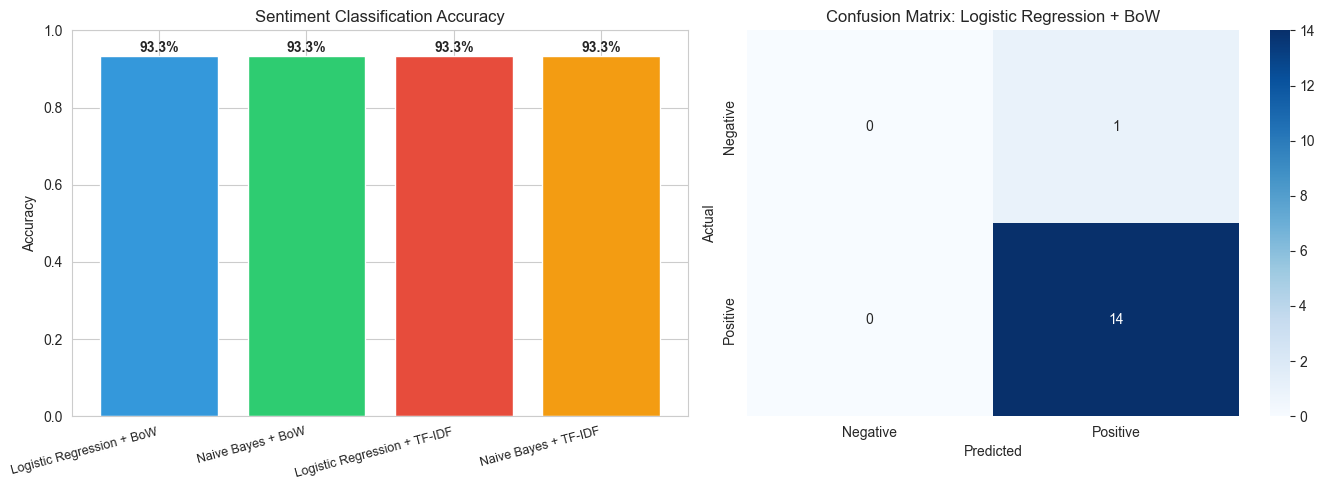


 Best Model: Logistic Regression + BoW with 93.3% accuracy


In [72]:
# TASK 7: SENTIMENT CLASSIFICATION
print("SENTIMENT CLASSIFICATION: Positive vs Negative Reviews")

# Create sentiment labels from ratings
# Positive: rating >= 4, Negative: rating <= 2, Neutral (3) excluded
df_sentiment = df.copy()
df_sentiment = df_sentiment.dropna(subset=['rating'])
df_sentiment['rating'] = pd.to_numeric(df_sentiment['rating'], errors='coerce')
df_sentiment = df_sentiment.dropna(subset=['rating'])

df_sentiment['sentiment'] = df_sentiment['rating'].apply(
    lambda r: 'positive' if r >= 4 else ('negative' if r <= 2 else 'neutral')
)

# Remove neutral reviews for binary classification
df_binary = df_sentiment[df_sentiment['sentiment'] != 'neutral'].reset_index(drop=True)
df_binary['label'] = (df_binary['sentiment'] == 'positive').astype(int)

print(f"\nDataset for classification:")
print(f"  Total reviews: {len(df_binary)}")
print(f"  Positive (rating ≥ 4): {(df_binary['label'] == 1).sum()}")
print(f"  Negative (rating ≤ 2): {(df_binary['label'] == 0).sum()}")

if len(df_binary) < 10:
    print("\n[!] Not enough labeled reviews for classification. Need at least 10.")
    print("    This may happen if ratings were not scraped properly.")
else:
    # Prepare features
    X_texts = df_binary['cleaned_text'].tolist()
    y = df_binary['label'].values

    # Split data
    X_train_text, X_test_text, y_train, y_test = train_test_split(
        X_texts, y, test_size=0.2, random_state=42, stratify=y
    )

    # BoW features
    bow_vec = CountVectorizer(max_features=5000)
    X_train_bow = bow_vec.fit_transform(X_train_text)
    X_test_bow = bow_vec.transform(X_test_text)

    # TF-IDF features
    tfidf_vec = TfidfVectorizer(max_features=5000)
    X_train_tfidf = tfidf_vec.fit_transform(X_train_text)
    X_test_tfidf = tfidf_vec.transform(X_test_text)

    print(f"\nTrain size: {len(X_train_text)}, Test size: {len(X_test_text)}")
    print(f"BoW features: {X_train_bow.shape[1]}, TF-IDF features: {X_train_tfidf.shape[1]}")

    # Train & Evaluate Models
    results = {}

    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'Naive Bayes': MultinomialNB()
    }

    feature_sets = {
        'BoW': (X_train_bow, X_test_bow),
        'TF-IDF': (X_train_tfidf, X_test_tfidf)
    }

    for feat_name, (X_train, X_test) in feature_sets.items():
        for model_name, model in models.items():
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            acc = accuracy_score(y_test, y_pred)
            key = f"{model_name} + {feat_name}"
            results[key] = {
                'accuracy': acc,
                'y_pred': y_pred,
                'report': classification_report(y_test, y_pred, target_names=['Negative', 'Positive'])
            }
            print(f"\n{'─'*60}")
            print(f"  {key}")
            print(f"{'─'*60}")
            print(f"  Accuracy: {acc:.4f} ({acc*100:.1f}%)")
            print(f"\n{results[key]['report']}")

    # Comparison Summary
    print("PERFORMANCE COMPARISON SUMMARY")

    
    summary_data = []
    for key, val in results.items():
        summary_data.append({
            'Model + Features': key,
            'Accuracy': f"{val['accuracy']*100:.1f}%"
        })
    summary_df = pd.DataFrame(summary_data)
    display(summary_df)

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy comparison bar chart
    model_names = list(results.keys())
    accuracies = [results[k]['accuracy'] for k in model_names]
    colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
    axes[0].bar(range(len(model_names)), accuracies, color=colors[:len(model_names)])
    axes[0].set_xticks(range(len(model_names)))
    axes[0].set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title('Sentiment Classification Accuracy')
    axes[0].set_ylim(0, 1)
    for i, v in enumerate(accuracies):
        axes[0].text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

    # Confusion matrix for best model
    best_key = max(results, key=lambda k: results[k]['accuracy'])
    cm = confusion_matrix(y_test, results[best_key]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')
    axes[1].set_title(f'Confusion Matrix: {best_key}')

    plt.tight_layout()
    plt.show()

    print(f"\n Best Model: {best_key} with {results[best_key]['accuracy']:.1%} accuracy")